In [1]:
import Pkg
Pkg.activate("../../.")


  Activating project at `~/dev/MyCloudAtlas.jl`


# EQB alpha/gamma grid search
Run equilibrium searches over a grid of (Lx, Lz) values using the shear-band guess strategy.
Stores unique equilibria and summary metrics (I, D, ||x||).

In [2]:
using CloudAtlas
using LinearAlgebra
using Random
using Statistics
using DelimitedFiles
using Printf
using Base.Threads


## Experiment parameters

In [3]:
# Discretization
J, K, L = 1, 3, 5

# Reynolds number
Re = 300.0

# Symmetry group (edit as needed)
sx, sy, sz, tx, tz = halfbox_symmetries()
# sxy, sztx
# H = [sx*sy*sz]
H = [sx * sy, sz * tx]

# Grid in physical box sizes
Lx_vals = range(5, 15; length=20)
Lz_vals = range(2, 10; length=20)

# Number of guesses per grid point
N = 1000

# Guess strategy
guess_strategy = :shear_band
shear_min, shear_max = 1.0, 3.0
rest_scale = 0.1
frac = 0.9        # fraction of |shear| mass for dominant modes
top_k = nothing   # alternatively choose a fixed number of dominant modes

# Accept/reject threshold for equilibria
norm_threshold = 1e-3
# Dedup tolerances
fp_tol = (cx = 1e-3, cz = 1e-3, nm = 2e-2, shear = 2e-2)

# Solver parameters
hookparams = SearchParams(ftol=1e-8, xtol=1e-10, Nnewton=25, Nhook=6, δ=0.02, verbosity=0)

# Output
out_dir = joinpath(@__DIR__, "eqb_alpha_gamma_grid")
mkpath(out_dir)
summary_path = joinpath(out_dir, "summary.csv")
completed_path = joinpath(out_dir, "completed_grid.csv")

# Resume + threading
resume_enabled = true
use_threads_grid = true


true

## Helpers

In [4]:
function solve_eqb(model, Re, xguess, hookparams)
    f = x -> model.f(x, Re)
    Df = x -> model.Df(x, Re)
    return hookstepsolve(f, Df, xguess, hookparams)
end

function summarize_solution(model, Dmat, x, Re)
    res = norm(model.f(x, Re)) / max(norm(x), eps(eltype(x)))
    I = power_input(model, x)
    D = dissipation_rate(Dmat, x)
    return (norm = norm(x), shear = I, dissipation = D, res = res)
end

function load_existing_results(summary_path)
    results = NamedTuple[]
    if !isfile(summary_path)
        return results
    end
    open(summary_path, "r") do io
        first = true
        for line in eachline(io)
            if first
                first = false
                continue
            end
            isempty(strip(line)) && continue
            vals = split(line, ',')
            length(vals) < 9 && continue
            Lx = parse(Float64, vals[1])
            Lz = parse(Float64, vals[2])
            α = parse(Float64, vals[3])
            γ = parse(Float64, vals[4])
            id = parse(Int, vals[5])
            normv = parse(Float64, vals[6])
            shearv = parse(Float64, vals[7])
            diss = parse(Float64, vals[8])
            res = parse(Float64, vals[9])
            push!(results, (Lx=Lx, Lz=Lz, α=α, γ=γ, id=id, norm=normv, shear=shearv, dissipation=diss, res=res))
        end
    end
    return results
end

function load_completed_grid(completed_path)
    done = Set{Tuple{Float64, Float64}}()
    if !isfile(completed_path)
        return done
    end
    open(completed_path, "r") do io
        first = true
        for line in eachline(io)
            if first
                first = false
                continue
            end
            isempty(strip(line)) && continue
            vals = split(line, ',')
            length(vals) < 2 && continue
            Lx = parse(Float64, vals[1])
            Lz = parse(Float64, vals[2])
            push!(done, (Lx, Lz))
        end
    end
    return done
end


function bootstrap_completed_from_summary(summary_path)
    done = Set{Tuple{Float64, Float64}}()
    if !isfile(summary_path)
        return done
    end
    open(summary_path, "r") do io
        first = true
        for line in eachline(io)
            if first
                first = false
                continue
            end
            isempty(strip(line)) && continue
            vals = split(line, ',')
            length(vals) < 2 && continue
            Lx = parse(Float64, vals[1])
            Lz = parse(Float64, vals[2])
            push!(done, (Lx, Lz))
        end
    end
    return done
end


function bootstrap_completed_from_filenames(out_dir)
    done = Set{Tuple{Float64, Float64}}()
    if !isdir(out_dir)
        return done
    end
    for f in readdir(out_dir)
        if occursin(r"^eqb_Lx", f) && endswith(f, ".asc")
            m = match(r"eqb_Lx([0-9\.]+)_Lz([0-9\.]+)_id\d+\.asc", f)
            if m !== nothing
                Lx = parse(Float64, m.captures[1])
                Lz = parse(Float64, m.captures[2])
                push!(done, (Lx, Lz))
            end
        end
    end
    return done
end


function is_completed(Lx, Lz, done_grid; atol=1e-3)
    for (Lx_d, Lz_d) in done_grid
        if isapprox(Lx, Lx_d; atol=atol) && isapprox(Lz, Lz_d; atol=atol)
            return true
        end
    end
    return false
end


is_completed (generic function with 1 method)

## Grid search

In [5]:
results = load_existing_results(summary_path)
done_grid = resume_enabled ? load_completed_grid(completed_path) : Set{Tuple{Float64, Float64}}()

# Bootstrap completed_grid.csv from filenames if needed
if resume_enabled && !isfile(completed_path)
    boot_done = bootstrap_completed_from_filenames(out_dir)
    open(completed_path, "w") do io
        println(io, "Lx,Lz")
        for (Lx, Lz) in sort!(collect(boot_done))
            println(io, "$(Lx),$(Lz)")
        end
    end
    done_grid = boot_done
end

# Bootstrap completed_grid.csv from summary.csv if needed
if resume_enabled && !isfile(completed_path)
    boot_done = bootstrap_completed_from_summary(summary_path)
    open(completed_path, "w") do io
        println(io, "Lx,Lz")
        for (Lx, Lz) in sort!(collect(boot_done))
            println(io, "$(Lx),$(Lz)")
        end
    end
    done_grid = boot_done
end

# Ensure headers exist
if !isfile(summary_path)
    open(summary_path, "w") do io
        println(io, "Lx,Lz,alpha,gamma,id,norm,shear,dissipation,residual")
    end
end
if !isfile(completed_path)
    open(completed_path, "w") do io
        println(io, "Lx,Lz")
    end
end

results_lock = ReentrantLock()
file_lock = ReentrantLock()
print_lock = ReentrantLock()

pairs = [(Lx, Lz) for Lx in Lx_vals for Lz in Lz_vals]

function process_grid_point(Lx, Lz)
    if resume_enabled && is_completed(Lx, Lz, done_grid; atol=1e-2)
        return
    end
    α = 2π / Lx
    γ = 2π / Lz
    lock(print_lock) do
        println("
=== Lx=$(Lx), Lz=$(Lz) (α=$(α), γ=$(γ)) ===")
    end

    model = ODEModel(α, γ, J, K, L, H)
    Dmat = build_dissipation_matrix(model)

    sols = Vector{Vector{Float64}}()
    fps = Vector{SolutionFingerprint}()

    rng = MersenneTwister(0xC0FFEE + threadid() + Int(round(Lx*1000)) + Int(round(Lz*1000)))

    for attempt in 1:N
        ξ_guess = build_guess(
            model, rng;
            strategy = guess_strategy,
            shear_min = shear_min,
            shear_max = shear_max,
            rest_scale = rest_scale,
            frac = frac,
            top_k = top_k,
        )
        x_guess, _, _ = extract_components(ξ_guess, model)

        x_sol, converged = solve_eqb(model, Re, x_guess, hookparams)
        if converged
            if norm(x_sol) <= norm_threshold
                continue
            end
            fp = fingerprint(model, x_sol)
            if is_distinct(fp, fps; tol = fp_tol)
                push!(fps, fp)
                push!(sols, x_sol)
                lock(print_lock) do
                    println("  + unique eqb: ||x||=$(round(norm(x_sol), digits=4)), shear=$(round(fp.shear, digits=4))")
                end
            end
        end
    end

    # Save solutions and summary rows
    for (i, x_sol) in enumerate(sols)
        fname = @sprintf("eqb_Lx%.4f_Lz%.4f_id%03d.asc", Lx, Lz, i)
        save(x_sol, joinpath(out_dir, fname))

        summ = summarize_solution(model, Dmat, x_sol, Re)
        row = (
            Lx = Lx, Lz = Lz, α = α, γ = γ, id = i,
            norm = summ.norm, shear = summ.shear, dissipation = summ.dissipation, res = summ.res
        )
        lock(results_lock) do
            push!(results, row)
        end
        lock(file_lock) do
            open(summary_path, "a") do io
                println(io, "$(row.Lx),$(row.Lz),$(row.α),$(row.γ),$(row.id),$(row.norm),$(row.shear),$(row.dissipation),$(row.res)")
            end
        end
    end

    lock(print_lock) do
        println("Found $(length(sols)) unique equilibria.")
    end

    # Mark grid point completed (even if no solutions)
    lock(file_lock) do
        open(completed_path, "a") do io
            println(io, "$(Lx),$(Lz)")
        end
    end
end

if use_threads_grid
    Threads.@threads for idx in eachindex(pairs)
        Lx, Lz = pairs[idx]
        process_grid_point(Lx, Lz)
    end
else
    for (Lx, Lz) in pairs
        process_grid_point(Lx, Lz)
    end
end



=== Lx=5.0, Lz=2.0 (α=1.2566370614359172, γ=3.141592653589793) ===

=== Lx=12.894736842105264, Lz=2.0 (α=0.48726743198535566, γ=3.141592653589793) ===

=== Lx=6.052631578947368, Lz=6.2105263157894735 (α=1.0380914855340186, γ=1.0116993291221368) ===

=== Lx=8.68421052631579, Lz=6.2105263157894735 (α=0.7235183080994675, γ=1.0116993291221368) ===

=== Lx=10.263157894736842, Lz=2.0 (α=0.6122077991610879, γ=3.141592653589793) ===

=== Lx=13.947368421052632, Lz=6.2105263157894735 (α=0.450492531458159, γ=1.0116993291221368) ===

=== Lx=11.31578947368421, Lz=6.2105263157894735 (α=0.5552582364484285, γ=1.0116993291221368) ===

=== Lx=7.631578947368421, Lz=2.0 (α=0.8233139368028423, γ=3.141592653589793) ===
J,K,L,m == 1,3,5,57
J,K,L,m == 1,3,5,57
J,K,L,m == 1,3,5,57
J,K,L,m == 1,3,5,57
(2J+1)(2K+1)(2L+1) + 1 == 232
J,K,L,m == 1,3,5,57
(2J+1)(2K+1)(2L+1) + 1 == 232
J,K,L,m == 1,3,5,57
J,K,L,m == 1,3,5,57
(2J+1)(2K+1)(2L+1) + 1 == 232
(2J+1)(2K+1)(2L+1) + 1 == 232
J,K,L,m == 1,3,5,57
(2J+1)(2K+1)

## Save summary CSV

In [6]:
# using DelimitedFiles
# using Printf

# # --- config (match your notebook) ---
# out_dir = joinpath(@__DIR__, "eqb_alpha_gamma_grid")
# summary_path = joinpath(out_dir, "summary.csv")

# J, K, L = 1, 3, 5
# Re = 300.0

# sx, sy, sz, tx, tz = halfbox_symmetries()
# H = [sx*sy*sz]

# # --- helpers ---
# function myreaddlm(filename; cc='%')
#     X = readdlm(filename, comments=true, comment_char=cc)
#     return size(X, 2) == 1 ? X[:, 1] : X
# end

# function summarize_solution(model, Dmat, x, Re)
#     res = norm(model.f(x, Re)) / max(norm(x), eps(eltype(x)))
#     I = power_input(model, x)
#     D = dissipation_rate(Dmat, x)
#     return (norm = norm(x), shear = I, dissipation = D, res = res)
# end

# function parse_eqb_filename(fname)
#     println(fname)
#     # m = match(r"eqb_Lx([0-9\\.]+)_Lz([0-9\\.]+)_id(\\d+)\\.asc", fname)
#     m = match(r"eqb_Lx([0-9\.]+)_Lz([0-9\.]+)_id(\d+)\.asc", fname)
#     println(m)
#     m === nothing && return nothing
#     Lx = parse(Float64, m.captures[1])
#     Lz = parse(Float64, m.captures[2])
#     id = parse(Int, m.captures[3])
#     return (Lx, Lz, id)
# end

# # for f in readdir(out_dir)
# #     if occursin(r"^eqb_Lx", f) && endswith(f, ".asc")
# #         m = match(r"eqb_Lx([0-9\.]+)_Lz([0-9\.]+)_id\d+\.asc", f)
# #         if m !== nothing
# #             Lx = parse(Float64, m.captures[1])
# #             Lz = parse(Float64, m.captures[2])
# #             push!(done, (Lx, Lz))
# #         end
# #     end
# # end

# # --- rebuild summary ---
# rows = NamedTuple[]
# for f in readdir(out_dir)
#     info = parse_eqb_filename(f)
#     # println("info is $(info)")
#     info === nothing && continue
#     Lx, Lz, id = info
#     α = 2π / Lx
#     γ = 2π / Lz

#     model = ODEModel(α, γ, J, K, L, H)
#     Dmat = build_dissipation_matrix(model)

#     x = myreaddlm(joinpath(out_dir, f))
#     summ = summarize_solution(model, Dmat, x, Re)

#     push!(rows, (
#         Lx = Lx, Lz = Lz, α = α, γ = γ, id = id,
#         norm = summ.norm, shear = summ.shear,
#         dissipation = summ.dissipation, res = summ.res
#     ))
# end

# open(summary_path, "w") do io
#     println(io, "Lx,Lz,alpha,gamma,id,norm,shear,dissipation,residual")
#     for r in rows
#         println(io, "$(r.Lx),$(r.Lz),$(r.α),$(r.γ),$(r.id),$(r.norm),$(r.shear),$(r.dissipation),$(r.res)")
#     end
# end

# println("Wrote summary to $summary_path")


In [7]:
# Rewrite summary.csv from in-memory results (dedup by Lx,Lz,id)
summary_path = joinpath(out_dir, "summary.csv")
seen = Set{Tuple{Float64, Float64, Int}}()
open(summary_path, "w") do io
    println(io, "Lx,Lz,alpha,gamma,id,norm,shear,dissipation,residual")
    for r in results
        key = (r.Lx, r.Lz, r.id)
        if key in seen
            continue
        end
        push!(seen, key)
        println(io, "$(r.Lx),$(r.Lz),$(r.α),$(r.γ),$(r.id),$(r.norm),$(r.shear),$(r.dissipation),$(r.res)")
    end
end
println("Wrote summary to $summary_path")


Wrote summary to /home/ebenq/dev/MyCloudAtlas.jl/notebooks/alpha_gamma_grid/eqb_alpha_gamma_grid/summary.csv


## Heatmap of unique equilibria
Counts of unique solutions per (Lx, Lz).

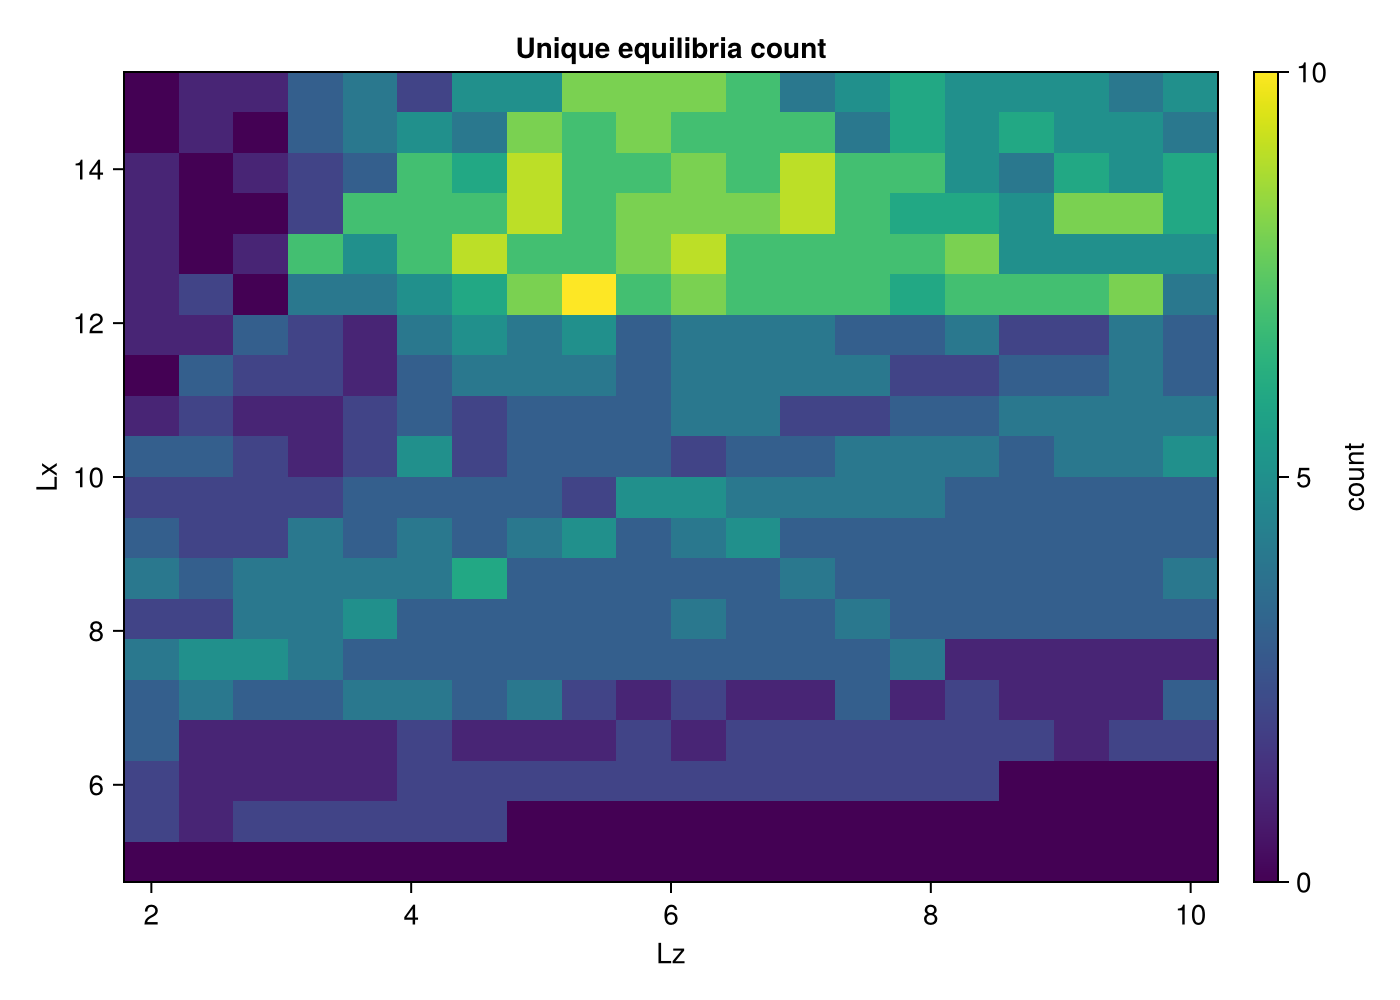

In [8]:
using CairoMakie

# Build a matrix of counts aligned with Lx_vals/Lz_vals
count_mat = zeros(Int, length(Lx_vals), length(Lz_vals))
for r in results
    i = findfirst(==(r.Lx), Lx_vals)
    j = findfirst(==(r.Lz), Lz_vals)
    count_mat[i, j] += 1
end

fig = Figure(size = (700, 500))
ax = Axis(fig[1, 1], xlabel = "Lz", ylabel = "Lx", title = "Unique equilibria count")
hm = heatmap!(ax, Lz_vals, Lx_vals, count_mat; colormap = :viridis)
Colorbar(fig[1, 2], hm, label = "count")
display(fig)

CairoMakie.save("heatmap.png", fig)

## Bifurcation diagrams for saved equilibria
Uses BifurcationKit to continue each saved equilibrium in Re and saves plots to disk.

In [9]:
import BifurcationKit as BK
using Plots
using Base.Threads


"""
    myreaddlm(filename, cc='%')

Read matrix or vector from a file, dropping comments marked with cc.
"""
function myreaddlm(filename; cc='#')
    X = readdlm(filename, comments=true, comment_char=cc)
    if size(X,2) == 1
        X = X[:,1]
    end
    X
end
bif_dir = joinpath(out_dir, "bifurcations")
mkpath(bif_dir)
min_re_path = joinpath(bif_dir, "min_re.csv")

# Continuation settings (edit as needed)
cont_Re_min = 100.0
cont_Re_max = 500.0
cont_max_steps = 2000
cont_dsmin = 1e-7
cont_dsmax = 1.0

use_threads_bifurcation = false

function continue_eqb(model, x0, Re0;
    Re_min = cont_Re_min,
    Re_max = cont_Re_max,
    max_steps = cont_max_steps,
    dsmin = cont_dsmin,
    dsmax = cont_dsmax)

    fp(x, p) = model.f(x, p[1])

    prob = BK.BifurcationProblem(
        fp,
        x0,
        [Float64(Re0)],
        1;
        record_from_solution = (x, p; k...) -> shear(x, model),
        plot_solution = (x, p; k...) -> shear(x, model),
    )

    newton_opts = BK.NewtonPar(1e-10, 25, false, BK.DefaultLS(), BK.DefaultEig(), false, 1.0, 0.01)
    cont_opts = BK.ContinuationPar(
        p_min = Re_min,
        p_max = Re_max,
        n_inversion = 20,
        dsmin = dsmin,
        dsmax = dsmax,
        max_steps = max_steps,
        newton_options = newton_opts
    )

    return BK.continuation(prob, BK.PALC(), cont_opts, bothside = true)
end

function min_re_from_branch(br)
    if hasproperty(br, :branch) && hasproperty(getproperty(br, :branch), :param)
        return minimum(getproperty(getproperty(br, :branch), :param))
    elseif hasproperty(br, :param)
        return minimum(getproperty(br, :param))
    else
        return NaN
    end
end

# ensure min_re header
if !isfile(min_re_path)
    open(min_re_path, "w") do io
        println(io, "Lx,Lz,id,min_Re")
    end
end


In [19]:
bif_lock = ReentrantLock()

using Plots
import BifurcationKit as BK
using DelimitedFiles

function get_state_vector(sol)
    if sol isa AbstractVector
        return sol
    elseif sol isa NamedTuple
        if haskey(sol, :x)
            return sol.x
        elseif haskey(sol, :u)
            return sol.u
        else
            error("NamedTuple solution does not contain :x or :u; keys=$(keys(sol))")
        end
    else
        error("Unsupported solution type: $(typeof(sol))")
    end
end

function extract_re_shear(br, model)
    Re_vals = hasproperty(br, :branch) ? collect(br.branch.param) : collect(br.param)

    sols = nothing
    if hasproperty(br, :branch) && hasproperty(br.branch, :sol)
        sols = br.branch.sol
    elseif hasproperty(br, :sol)
        sols = br.sol
    end
    sols === nothing && error("No solutions found in ContResult")

    shear_vals = similar(Re_vals)
    for i in eachindex(Re_vals)
        x = get_state_vector(sols[i])
        shear_vals[i] = shear(x, model)
    end
    return Re_vals, shear_vals
end



function process_bifurcation(r; out_dir, bif_dir, min_re_path, Re, J, K, L, H)
    α = r.α
    γ = r.γ
    Lx = r.Lx
    Lz = r.Lz

    model = ODEModel(α, γ, J, K, L, H)

    fname = @sprintf("eqb_Lx%.4f_Lz%.4f_id%03d.asc", Lx, Lz, r.id)
    x0 = myreaddlm(joinpath(out_dir, fname))

    br = continue_eqb(model, x0, Re)

    # Extract Re/shear and save CSV
    Re_vals, shear_vals = extract_re_shear(br, model)
    csv_path = joinpath(bif_dir, @sprintf("bif_Lx%.4f_Lz%.4f_id%03d.csv", Lx, Lz, r.id))
    open(csv_path, "w") do io
        println(io, "Re,shear")
        for i in eachindex(Re_vals)
            println(io, "$(Re_vals[i]),$(shear_vals[i])")
        end
    end

    # Plot and save PNG (explicit Plots prefix)
    plt = Plots.plot(Re_vals, shear_vals;
        title = "EQB continuation Lx=$(Lx), Lz=$(Lz), id=$(r.id)",
        xlabel = "Re",
        ylabel = "I (shear)"
    )
    out_png = joinpath(bif_dir, @sprintf("bif_Lx%.4f_Lz%.4f_id%03d.png", Lx, Lz, r.id))
    Plots.savefig(plt, out_png)

    # Save min Re
    min_Re = minimum(Re_vals)
    open(min_re_path, "a") do io
        println(io, "$(Lx),$(Lz),$(r.id),$(min_Re)")
    end

    println("Saved: $out_png and $csv_path")
end


process_bifurcation (generic function with 1 method)

In [ ]:
bif_dir = joinpath(out_dir, "bifurcations")
mkpath(bif_dir)
min_re_path = joinpath(bif_dir, "min_re.csv")
if !isfile(min_re_path)
    open(min_re_path, "w") do io
        println(io, "Lx,Lz,id,min_Re")
    end
end

for r in results
    process_bifurcation(r;
        out_dir = out_dir,
        bif_dir = bif_dir,
        min_re_path = min_re_path,
        Re = Re,
        J = J, K = K, L = L,
        H = H
    )
end


J,K,L,m == 1,3,5,57
(2J+1)(2K+1)(2L+1) + 1 == 232
Making matrices B,A1,A2,S3...
Making quadratic operator N...
1 2 3 4 5 6 7 8 9 10 11 12 13 14 15 16 17 18 19 20 21 22 23 24 25 26 27 28 29 30 31 32 33 34 35 36 37 38 39 40 41 42 43 44 45 46 47 48 49 50 

┌ Error: Failure to converge with given tolerance = 1.0e-10.
│ Step = 139
│ You can decrease the tolerance or pass a different norm using the argument `normC`.
│ We reached the smallest value [dsmin] valid for ds, namely 1.0e-7.
│ Stopping continuation at continuation step 139.
└ @ BifurcationKit ~/.julia/packages/BifurcationKit/q52qN/src/continuation/Contbase.jl:70


51 52 53 54 55 56 57 
Saved: /home/ebenq/dev/MyCloudAtlas.jl/notebooks/alpha_gamma_grid/eqb_alpha_gamma_grid/bifurcations/bif_Lx13.9474_Lz6.2105_id001.png and /home/ebenq/dev/MyCloudAtlas.jl/notebooks/alpha_gamma_grid/eqb_alpha_gamma_grid/bifurcations/bif_Lx13.9474_Lz6.2105_id001.csv
J,K,L,m == 1,3,5,57
(2J+1)(2K+1)(2L+1) + 1 == 232
Making matrices B,A1,A2,S3...
Making quadratic operator N...
1 2 3 4 

┌ Error: Failure to converge with given tolerance = 1.0e-10.
│ Step = 267
│ You can decrease the tolerance or pass a different norm using the argument `normC`.
│ We reached the smallest value [dsmin] valid for ds, namely 1.0e-7.
│ Stopping continuation at continuation step 267.
└ @ BifurcationKit ~/.julia/packages/BifurcationKit/q52qN/src/continuation/Contbase.jl:70


5 6 7 8 9 10 11 12 13 14 15 16 17 18 19 20 21 22 23 24 25 26 27 28 29 30 31 32 33 34 35 36 37 38 39 40 41 42 43 44 45 46 47 48 49 50 51 52 53 54 55 56 57 
Saved: /home/ebenq/dev/MyCloudAtlas.jl/notebooks/alpha_gamma_grid/eqb_alpha_gamma_grid/bifurcations/bif_Lx13.9474_Lz6.2105_id002.png and /home/ebenq/dev/MyCloudAtlas.jl/notebooks/alpha_gamma_grid/eqb_alpha_gamma_grid/bifurcations/bif_Lx13.9474_Lz6.2105_id002.csv
J,K,L,m == 1,3,5,57
(2J+1)(2K+1)(2L+1) + 1 == 232
Making matrices B,A1,A2,S3...
Making quadratic operator N...
1 2 3 4 5 6 7 8 9 10 11 12 13 14 15 16 17 18 19 20 21 22 23 24 25 26 27 28 29 30 

...

33 34 35 36 37 38 39 40 41 42 43 44 45 46 47 48 49 50 51 52 53 54 55 56 57 
Saved: /home/ebenq/dev/MyCloudAtlas.jl/notebooks/alpha_gamma_grid/eqb_alpha_gamma_grid/bifurcations/bif_Lx6.0526_Lz7.0526_id001.png and /home/ebenq/dev/MyCloudAtlas.jl/notebooks/alpha_gamma_grid/eqb_alpha_gamma_grid/bifurcations/bif_Lx6.0526_Lz7.0526_id001.csv
J,K,L,m == 1,3,5,57
(2J+1)(2K+1)(2L+1) + 1 == 232
Making matrices B,A1,A2,S3...
Making quadratic operator N...
1 2 3 4 5 6 7 8 9 10 11 12 13 14 15 16 17 18 19 20 21 22 23 24 25 26 27 28 29 30 31 32 

┌ Error: Failure to converge with given tolerance = 1.0e-10.
│ Step = 76
│ You can decrease the tolerance or pass a different norm using the argument `normC`.
│ We reached the smallest value [dsmin] valid for ds, namely 1.0e-7.
│ Stopping continuation at continuation step 76.
└ @ BifurcationKit ~/.julia/packages/BifurcationKit/q52qN/src/continuation/Contbase.jl:70


33 34 35 36 37 38 39 40 41 42 43 44 45 46 47 48 49 50 51 52 53 54 55 56 57 
Saved: /home/ebenq/dev/MyCloudAtlas.jl/notebooks/alpha_gamma_grid/eqb_alpha_gamma_grid/bifurcations/bif_Lx6.0526_Lz7.0526_id002.png and /home/ebenq/dev/MyCloudAtlas.jl/notebooks/alpha_gamma_grid/eqb_alpha_gamma_grid/bifurcations/bif_Lx6.0526_Lz7.0526_id002.csv
J,K,L,m == 1,3,5,57
(2J+1)(2K+1)(2L+1) + 1 == 232
Making matrices B,A1,A2,S3...
Making quadratic operator N...
1 2 3 4 5 6 7 8 9 10 11 12 13 14 15 16 17 18 19 20 21 22 23 24 25 26 27 28 29 30 31 32 33 34 35 36 37 38 39 40 41 42 43 44 45 46 47 48 49 50 51 52 53 54 55 56 57 
Saved: /home/ebenq/dev/MyCloudAtlas.jl/notebooks/alpha_gamma_grid/eqb_alpha_gamma_grid/bifurcations/bif_Lx13.9474_Lz7.0526_id001.png and /home/ebenq/dev/MyCloudAtlas.jl/notebooks/alpha_gamma_grid/eqb_alpha_gamma_grid/bifurcations/bif_Lx13.9474_Lz7.0526_id001.csv
J,K,L,m == 1,3,5,57
(2J+1)(2K+1)(2L+1) + 1 == 232
Making matrices B,A1,A2,S3...
Making quadratic operator N...
1 2 3 4 5 6 7 8

┌ Error: Failure to converge with given tolerance = 1.0e-10.
│ Step = 112
│ You can decrease the tolerance or pass a different norm using the argument `normC`.
│ We reached the smallest value [dsmin] valid for ds, namely 1.0e-7.
│ Stopping continuation at continuation step 112.
└ @ BifurcationKit ~/.julia/packages/BifurcationKit/q52qN/src/continuation/Contbase.jl:70


33 34 35 36 37 38 39 40 41 42 43 44 45 46 47 48 49 50 51 52 53 54 55 56 57 
Saved: /home/ebenq/dev/MyCloudAtlas.jl/notebooks/alpha_gamma_grid/eqb_alpha_gamma_grid/bifurcations/bif_Lx8.6842_Lz7.0526_id001.png and /home/ebenq/dev/MyCloudAtlas.jl/notebooks/alpha_gamma_grid/eqb_alpha_gamma_grid/bifurcations/bif_Lx8.6842_Lz7.0526_id001.csv
J,K,L,m == 1,3,5,57
(2J+1)(2K+1)(2L+1) + 1 == 232
Making matrices B,A1,A2,S3...
Making quadratic operator N...
1 2 3 4 5 6 7 8 9 10 11 12 13 14 15 16 17 18 19 20 21 22 23 24 

In [16]:
?shear

search: shear Char shear_min shear_max isreal stderr



No documentation found for public binding `CloudAtlas.shear`.

`CloudAtlas.shear` is a `Function`.

```
# 1 method for generic function "shear" from CloudAtlas:
 [1] shear(x::Vector{T}, model::ODEModel{T}) where T<:Real
     @ ~/dev/MyCloudAtlas.jl/src/ODEModels.jl:125
```
